series count: 103
X shape: (103, 42)
labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
cluster counts:
cluster 0 : 101
cluster 1 : 1
cluster 2 : 1
最少クラスタ: 1
該当CSV:
06_WETH_stargate-bridged-weth-fuse_last90d_usd.csv


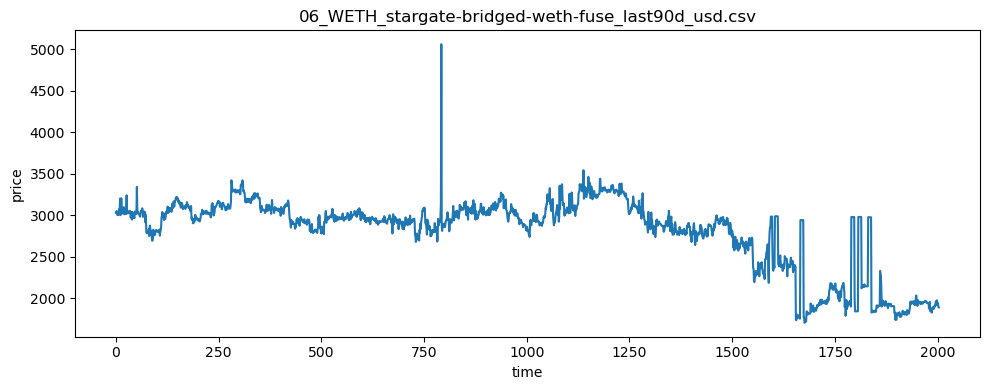

In [4]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from collections import Counter
from tslearn.clustering import TimeSeriesKMeans

# ==========================
# CSV読み込み
# ==========================
path = r"D:\musashino-university\finance\cc\*.csv"
files = glob.glob(path)

dfs = {}

for f in files:
    name = f.split("\\")[-1]
    df = pd.read_csv(f)

    # priceを数値化
    if "price" not in df.columns:
        print("price列なし:", name)
        continue

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["price"]).reset_index(drop=True)

    if len(df) > 10:
        dfs[name] = df

print("series count:", len(dfs))

# ==========================
# 時系列作成
# ==========================
names = list(dfs.keys())

min_len = min(len(df["price"]) for df in dfs.values())

series_list = []

for df in dfs.values():
    series_list.append(df["price"].values[:min_len])

X = np.array(series_list, dtype=float)

print("X shape:", X.shape)

# ==========================
# クラスタリング
# ==========================
model = TimeSeriesKMeans(
    n_clusters=3,
    metric="dtw",
    max_iter=20,
    random_state=0
)

labels = model.fit_predict(X)

print("labels:", labels)

# ==========================
# クラスタ数
# ==========================
cluster_counts = Counter(labels)

print("cluster counts:")
for k, v in cluster_counts.items():
    print("cluster", k, ":", v)

# ==========================
# 最少クラスタ
# ==========================
minority_cluster = min(cluster_counts, key=cluster_counts.get)

print("最少クラスタ:", minority_cluster)

minority_idx = np.where(labels == minority_cluster)[0]

minority_names = [names[i] for i in minority_idx]

print("該当CSV:")
for n in minority_names:
    print(n)

# ==========================
# 該当CSVだけプロット
# ==========================
for name in minority_names:

    file = path.replace("*.csv", name)

    df = pd.read_csv(file)

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df = df.dropna(subset=["price"])

    y = df["price"].values

    plt.figure(figsize=(10,4))
    plt.plot(y)
    plt.title(name)
    plt.xlabel("time")
    plt.ylabel("price")
    plt.tight_layout()
    plt.show()